# BASE MODEL

In [19]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import random
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import lightning as pl
import torchmetrics
import comet_ml
import os
from lightning.pytorch import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from comet_ml import Experiment
import pandas as pd
import numpy as np
from mediapipe_handcrop import MediapipeHandCrop
from tqdm import tqdm

## CUDA SETUP

In [20]:
def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        torch.set_default_dtype(torch.float32)
    else:
        device = torch.device('cpu')
        torch.set_default_dtype(torch.float32)
    return device

device = setup_device()
print(f"Using {device} device")

# Set random seed for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using cuda device


## DATASET

In [21]:
import ast

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Values calculated from the ImageNet dataset
])

class Dataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.csv_file = csv_file
        self.transform = transform
        self.df = pd.read_csv(self.csv_file)
        self.classes = sorted(np.unique(self.df["class_index"]))
        self.class_names = sorted(np.unique(self.df["class_name"]))
        
    def __len__(self):
        dataset_len = len(self.df)
        return dataset_len
    
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("Index out of bounds")
        
        label = self.df.loc[index, "class_index"]
        image_path = self.df.loc[index, "image_path"]
        characteristic_vectors_str = self.df.loc[index, "characteristic_vectors"]

        # Konwersja wektorów charakterystycznych
        characteristic_vectors = ast.literal_eval(characteristic_vectors_str)  
        characteristic_vectors = np.array(characteristic_vectors, dtype=np.float32)

        # Ładowanie obrazu
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        # Konwersja do RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Przekształcenia obrazu
        if self.transform:
            image = self.transform(Image.fromarray(image))

        # Skalowanie wektorów
        original_height, original_width = 64, 64  # Docelowe wymiary po transformacji
        characteristic_vectors[:, 0] *= (image.shape[2] / original_width)
        characteristic_vectors[:, 1] *= (image.shape[1] / original_height)

        return image, label, characteristic_vectors
        

In [22]:
# Train dataset and dataloader initialization
train_dataset = Dataset(root_dir="./newest_dataset/validated_train/",
                        csv_file= "./newest_dataset/validated_train_csv.csv",
                        transform=transform)

Dataset len:
132881

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:

Image size:
torch.Size([3, 64, 64])


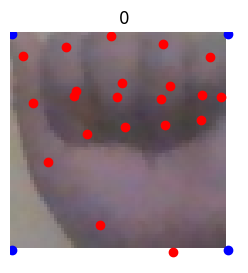

Characteristic vectors: 
[[47.908943  64.68564  ]
 [26.105608  56.82017  ]
 [10.868636  37.973804 ]
 [ 6.3895097 20.537067 ]
 [ 3.384686   6.5762563]
 [19.01431   16.905693 ]
 [15.957447   4.009805 ]
 [18.414295  18.517794 ]
 [22.200596  29.729116 ]
 [32.66328   14.630009 ]
 [29.455763   0.5805693]
 [31.072258  18.707493 ]
 [33.722107  27.753008 ]
 [46.99127   15.423347 ]
 [44.827404   2.941013 ]
 [44.347733  19.298271 ]
 [45.338875  27.188318 ]
 [62.115143  18.79603  ]
 [58.67883    6.7766824]
 [56.4936    18.237299 ]
 [56.179028  25.475674 ]]


In [23]:
# Sanity check
print("Dataset len:")
print(len(train_dataset))

print("\nDataset classes:")
print(train_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = train_dataset[random.randint(0, len(train_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]

print('\nImage size:')
print(img.shape)

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
plt.scatter([0, 0, img.shape[2], img.shape[2]], [0, img.shape[1], img.shape[1], 0], c="blue")  

plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)


In [24]:
# Train dataset and dataloader initialization
test_dataset = Dataset(root_dir="./newest_dataset/validated_test/",
                        csv_file= "./newest_dataset/validated_test_csv.csv",
                        transform=transform)

Dataset len:
674

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:

Image size:
torch.Size([3, 64, 64])


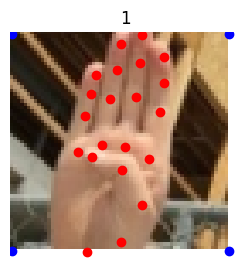

Characteristic vectors: 
[[22.173536  64.24601  ]
 [32.164036  61.327164 ]
 [38.308273  50.53385  ]
 [32.517784  39.992737 ]
 [23.601995  36.220726 ]
 [40.536926  36.83447  ]
 [43.737534  22.990627 ]
 [44.68633   14.4078   ]
 [44.73824    6.931826 ]
 [33.294918  33.310642 ]
 [36.588352  18.535006 ]
 [37.89085    8.667719 ]
 [38.425056   0.3217386]
 [26.571405  32.901848 ]
 [29.051405  19.321827 ]
 [31.039625  10.592866 ]
 [32.227055   2.9898634]
 [19.535522  34.8754   ]
 [21.464664  24.346813 ]
 [23.254938  17.873451 ]
 [24.801159  12.03935  ]]


In [25]:
# Sanity check
print("Dataset len:")
print(len(test_dataset))

print("\nDataset classes:")
print(test_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = test_dataset[random.randint(0, len(test_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]
print('\nImage size:')
print(img.shape)

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
plt.scatter([0, 0, img.shape[2], img.shape[2]], [0, img.shape[1], img.shape[1], 0], c="blue")  # Granice prostokąta

plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)

## SPLITING DATA INTO TRAINING AND VALIDATION DATASETS

In [26]:
train_len = round(0.8 * len(train_dataset))
val_len = len(train_dataset) - train_len
train_len, val_len, train_len + val_len == len(train_dataset)

(106305, 26576, True)

In [27]:
train_dataset_, val_dataset = random_split(train_dataset, [train_len, val_len])

In [28]:
# Sanity check once more

print(f"Number of training samples: {len(train_dataset_)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of train classes: {len(train_dataset_.dataset.classes)}")
print(f"Number of val classes: {len(val_dataset.dataset.classes)}")
print(f"Number of test samples: {len(test_dataset)}") 


Number of training samples: 106305
Number of validation samples: 26576
Number of train classes: 26
Number of val classes: 26
Number of test samples: 674


In [29]:
print(f"Train dataset classes: {train_dataset.classes}")
print(f"Validation dataset classes: {train_dataset.classes}")

Train dataset classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Validation dataset classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## DATALOADERS

In [30]:
import os
num_workers = os.cpu_count()
print(f"Suggested num_workers: {num_workers}")

Suggested num_workers: 24


In [31]:
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  # Use 'spawn' to safely initialize workers

train_dataloader = DataLoader(train_dataset_, 
                              batch_size=32, 
                              shuffle=True,
                              pin_memory=True)

val_dataloader = DataLoader(val_dataset,
                            batch_size=32,
                            shuffle=False,
                            pin_memory=True)

test_dataloader = DataLoader(test_dataset, 
                             batch_size=32, 
                             shuffle=False,
                             pin_memory=True)


In [32]:
# Sanity check
def loader_sanity_check(loader):
    for batch_idx, (data, labels, characteristic_vectors) in enumerate(loader):
        print(f"Batch nr: {batch_idx}")
        print(f"Batch size: {data.shape[0]}")
        print(f"Data shape: {data.shape}")
        print(f"Image shape: {data[0].shape}")
        print(f"Characteristic vectors shape: {len(characteristic_vectors)}")
        print(f"Characteristic vectors: {characteristic_vectors}")
        print(f"Classes: {labels}")
        print(f"Num classes: {len(labels)}")
        break

In [33]:
loader_sanity_check(train_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[21.3307, 64.4998],
         [38.0635, 57.0929],
         [50.0569, 45.0713],
         ...,
         [16.0657,  6.0160],
         [28.6792,  6.2752],
         [36.1676, 12.6773]],

        [[31.1358, 64.9898],
         [43.8342, 55.0405],
         [53.6805, 40.4984],
         ...,
         [11.4321, 28.3594],
         [15.2625, 37.5517],
         [18.0594, 46.2163]],

        [[21.9984, 64.5701],
         [41.6766, 56.5427],
         [57.7612, 41.7272],
         ...,
         [ 7.5720, 18.1867],
         [13.1272, 31.7734],
         [16.1945, 41.7379]],

        ...,

        [[26.1893, 64.5107],
         [40.8486, 59.5801],
         [49.1868, 44.7437],
         ...,
         [16.1233, 17.1463],
         [16.3335,  8.4175],
         [16.4751,  0.4375]],

        [[28.3371, 64.1330],
         [42.3704, 55.5766],
       

In [34]:
loader_sanity_check(val_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[12.6558, 62.4811],
         [25.1847, 64.1338],
         [40.5941, 57.1287],
         ...,
         [22.8931, 22.2612],
         [26.3939, 14.8748],
         [30.0422,  7.8492]],

        [[24.9750, 65.1678],
         [39.9501, 57.6989],
         [47.1551, 40.9637],
         ...,
         [18.1752, 16.1314],
         [17.9339,  7.5419],
         [18.1519,  0.2263]],

        [[36.8581, 56.1127],
         [52.9785, 49.9268],
         [65.2907, 42.4494],
         ...,
         [ 3.0641, 43.6537],
         [11.4313, 52.9005],
         [18.1412, 53.6922]],

        ...,

        [[22.8918, 64.2849],
         [37.3952, 46.4946],
         [42.5695, 31.5457],
         ...,
         [25.3541,  9.4860],
         [37.4238, 10.3063],
         [44.4409, 14.8121]],

        [[37.0255, 12.7535],
         [51.0274, 13.9551],
       

In [35]:
loader_sanity_check(test_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[ 7.1326, 62.4355],
         [28.6861, 60.4777],
         [49.9131, 45.6650],
         ...,
         [ 6.2890, 10.9291],
         [ 7.8201, 26.7674],
         [ 8.3716, 37.7560]],

        [[ 5.8576, 57.6342],
         [26.7703, 59.6616],
         [48.0776, 40.9094],
         ...,
         [ 7.2527, 10.1613],
         [ 6.5580, 26.1311],
         [ 5.7348, 36.1081]],

        [[ 5.8957, 60.1201],
         [27.1208, 59.0330],
         [47.5304, 42.6835],
         ...,
         [ 6.6615, 11.1107],
         [ 6.4246, 27.3819],
         [ 6.0614, 37.7908]],

        ...,

        [[26.5988, 64.1663],
         [36.5560, 59.6189],
         [43.4383, 47.9348],
         ...,
         [22.0566, 23.1919],
         [23.1683, 17.1042],
         [24.1680, 11.5004]],

        [[26.0426, 64.0471],
         [36.3126, 59.0488],
       

## COMET_ML SETUP

In [36]:
from comet_ml import Experiment

# Initialize Comet.ml experiment
experiment = Experiment(
    api_key=os.getenv("COMET_API_KEY"),
    project_name="DLF-sign_letters_classification",
)

experiment.set_name("Base model resnet")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: Not all initial data has been logged for experiment 4386b74b55734d3ebc6fadb19cc1bdec, call Experiment.end() to ensure that all data to have been logged
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Base model resnet
COMET INFO:     url                   : https://www.comet.com/ziemmi13/dlf-sign-letters-classification/4386b74b55734d3ebc6fadb19cc1bdec
COMET INFO:   Others:
COMET INFO:     Name : Base model resnet
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     git metadata        : 1
COMET INFO:     installed

## Define helper functions to logs gradients and weights

In [37]:
def to_numpy(x):
    return x.detach().numpy()


def update_gradient_map(model, gradmap):
    for name, layer in zip(model._modules, model.children()):
        if "activ" in name:
            continue

        if not hasattr(layer, "weight"):
            continue

        wname = "%s/%s.%s" % ("gradient", name, "weight")
        bname = "%s/%s.%s" % ("gradient", name, "bias")

        gradmap.setdefault(wname, 0)
        gradmap.setdefault(bname, 0)

        gradmap[wname] += layer.weight.grad
        gradmap[bname] += layer.bias.grad

    return gradmap


def log_gradients(gradmap, step):
    for k, v in gradmap.items():
        experiment.log_histogram_3d(to_numpy(v), name=k, step=step)


def log_weights(model, step):
    for name, layer in zip(model._modules, model.children()):
        if "activ" in name:
            continue

        if not hasattr(layer, "weight"):
            continue

        wname = "%s.%s" % (name, "weight")
        bname = "%s.%s" % (name, "bias")

        experiment.log_histogram_3d(to_numpy(layer.weight), name=wname, step=step)
        experiment.log_histogram_3d(to_numpy(layer.bias), name=bname, step=step)

## BASE MODEL

In [41]:
class BaseModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # Image processing branch (ResNet50)
        self.base_model = models.resnet50(pretrained=True)
        self.base_model = nn.Sequential(*list(self.base_model.children())[:-1])
        
        # Freeze feature extractor
        for param in self.base_model.parameters():
            param.requires_grad = False
        
        # Image branch fully connected layers
        self.fc_image = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.LayerNorm(1024),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.3)
        )
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.LayerNorm(128),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, images):
        # Process images through ResNet
        x = self.base_model(images)
        x = torch.flatten(x, 1)
        image_features = self.fc_image(x)
        
        # Final classification
        output = self.classifier(image_features)
        return output


In [42]:
num_classes = len(train_dataset_.dataset.classes)
model = BaseModel(num_classes=num_classes)
model.to(device)

C:\Users\Hyperbook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Hyperbook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


BaseModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d

## MODEL PARAMETERS

In [43]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"All parameters: {total_params}")
print(f"Frozen parameters: {frozen_params}")
print(f"Trainable parameters: {trainable_params}")


All parameters: 26302426
Frozen parameters: 23508032
Trainable parameters: 2794394


In [45]:
learning_rate = 0.0001
batch_size = 32
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # https://paperswithcode.com/method/weight-decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3) # https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
num_epochs = 15

hyper_params = {"batch_size": batch_size, "num_epochs": num_epochs, "learning_rate": learning_rate}
experiment.log_parameters(hyper_params)

In [46]:
def train_model(device, model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler, resume_path=None, early_stopping_patience=5):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')  
    # epochs_no_improve = 0

    # Load checkpoint if provided
    start_epoch = 0
    if resume_path:
        checkpoint = torch.load(resume_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")

    model.to(device)
    print(f"Starting Training")

    for epoch in range(start_epoch, num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        gradmap = {}

        for batch_idx, (images, labels, characteristic_vectors) in enumerate(train_loader):
            # Convert characteristic vectors to tensor
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)  # Pass both images and characteristic vectors

            loss = criterion(outputs, labels)
            loss.backward()

            # Update gradient map
            gradmap = update_gradient_map(model, gradmap)

            optimizer.step()

            # Accumulate batch loss
            running_loss += loss.item()

            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            # Log every 100 batches
            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch + 1}, Batch: {batch_idx}, Loss: {loss.item():.4f}')
                experiment.log_metric("train_loss", loss.item(), step=epoch * len(train_loader) + batch_idx)

        # Log gradients
        log_gradients(gradmap, epoch)

        # Calculate epoch metrics
        epoch_loss = running_loss / len(train_loader.dataset)  # Average loss per sample
        train_accuracy = 100. * train_correct / train_total
        train_losses.append(epoch_loss)

        # Log epoch metrics
        experiment.log_metric("epoch_train_loss", epoch_loss, step=epoch)
        experiment.log_metric("epoch_train_accuracy", train_accuracy, step=epoch)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        print("Validating...")
        with torch.inference_mode():
            for images, labels, characteristic_vectors in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)  
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_epoch_loss = val_loss / len(val_loader.dataset)  # Average loss per sample
        val_accuracy = 100. * val_correct / val_total
        val_losses.append(val_epoch_loss)

        print(f'Epoch [{epoch + 1}/{num_epochs}]')
        print(f'Training Loss: {epoch_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
        print(f'Validation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        print('-' * 60)

        # Log validation metrics
        experiment.log_metric("val_loss", val_epoch_loss, step=epoch)
        experiment.log_metric("val_accuracy", val_accuracy, step=epoch)

        # Adjust learning rate using scheduler
        scheduler.step(val_epoch_loss)

        # Log weights
        log_weights(model, epoch)

        # Save best model checkpoint
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            best_epoch = epoch
            epochs_no_improve = 0

            best_checkpoint_path = f"./models/base_model/checkpoints/best_model.pt"
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, best_checkpoint_path)

            print(f"Best model updated and saved at: {best_checkpoint_path}")
        else:
            epochs_no_improve += 1

        # Early stopping check
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered. No improvement in validation loss for {early_stopping_patience} consecutive epochs.")
            break

        # Save model checkpoint
        checkpoint_path = f"./models/multimodal_model/checkpoints/Epoch {epoch+1}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }, checkpoint_path)

        print(f"Model checkpoint saved at: {checkpoint_path}")

        model_path = f"./models/base_model/checkpoints/model epoch {epoch+1}"
        weights_path = f"./models/base_model/checkpoints/model weights epoch {epoch+1}"

        torch.save(model, model_path)
        torch.save(model.state_dict(), weights_path)

        print(f"Model checkpoint saved at: {checkpoint_path}")

    return train_losses, val_losses


In [47]:
# Test loop
def test_model(device, model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for i, (images, labels, characteristic_vectors) in enumerate(test_loader):
            images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)
            outputs = model(images)  # Pass both images and characteristic vectors
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100 * correct / total

    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

    # # Log test metrics
    # experiment.log_metric("test_loss", test_loss)
    # experiment.log_metric("test_accuracy", test_accuracy)

    return test_loss, test_accuracy


## TRAINING

In [48]:
train_losses, val_losses = train_model(device, model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs, scheduler)

Starting Training
Epoch: 1, Batch: 0, Loss: 3.4905
Epoch: 1, Batch: 100, Loss: 3.2820
Epoch: 1, Batch: 200, Loss: 2.9173
Epoch: 1, Batch: 300, Loss: 2.3461
Epoch: 1, Batch: 400, Loss: 2.2224
Epoch: 1, Batch: 500, Loss: 2.0666
Epoch: 1, Batch: 600, Loss: 2.1246
Epoch: 1, Batch: 700, Loss: 1.3178
Epoch: 1, Batch: 800, Loss: 1.6043
Epoch: 1, Batch: 900, Loss: 1.5343
Epoch: 1, Batch: 1000, Loss: 1.4224
Epoch: 1, Batch: 1100, Loss: 1.2207
Epoch: 1, Batch: 1200, Loss: 1.2732
Epoch: 1, Batch: 1300, Loss: 0.8342
Epoch: 1, Batch: 1400, Loss: 0.9273
Epoch: 1, Batch: 1500, Loss: 1.0202
Epoch: 1, Batch: 1600, Loss: 1.0216
Epoch: 1, Batch: 1700, Loss: 0.7574
Epoch: 1, Batch: 1800, Loss: 0.9407
Epoch: 1, Batch: 1900, Loss: 0.9123
Epoch: 1, Batch: 2000, Loss: 0.9545
Epoch: 1, Batch: 2100, Loss: 1.1386
Epoch: 1, Batch: 2200, Loss: 0.5342
Epoch: 1, Batch: 2300, Loss: 0.7347
Epoch: 1, Batch: 2400, Loss: 1.2144
Epoch: 1, Batch: 2500, Loss: 0.9152
Epoch: 1, Batch: 2600, Loss: 0.5412
Epoch: 1, Batch: 2700,

In [49]:
# Saving model and weights
torch.save(model, "./models/base_model/base_model")
torch.save(model.state_dict(), "./models/multimodal_model/base_model_weights")

## Log the Model to Comet

In [50]:
from comet_ml.integration.pytorch import log_model

log_model(experiment, model, "Base model")

## End Experiment

In [51]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Base model resnet
COMET INFO:     url                   : https://www.comet.com/ziemmi13/dlf-sign-letters-classification/caec02681f724a09b4522ae4d0d3bafa
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     epoch_train_accuracy [15] : (64.98001034758478, 95.87695781007479)
COMET INFO:     epoch_train_loss [15]     : (0.004509816241589161, 0.040478021719315437)
COMET INFO:     train_loss [510]          : (0.011017421260476112, 3.490544557571411)
COMET INFO:     val_accuracy [15]         : (85.79921733895245, 97.54289584587598)
COMET INFO:     val_loss [15]             : (0.0025847969945648214, 0.01540662832434801)
COMET INFO:   Others:
COMET INFO

## TESTING

In [52]:
test_loss, test_accuracy = test_model(device, model, test_dataloader, criterion)

Test Loss: 0.0131, Test Accuracy: 89.76%


# TESTING ON A DIFFERENT DATASET

In [53]:
model = torch.load(f="./models/base_model/base_model", weights_only=False)
model.to(device)

BaseModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d

In [54]:
import ast

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Values calculated from the ImageNet dataset
])

class Dataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.csv_file = csv_file
        self.transform = transform
        self.df = pd.read_csv(self.csv_file)
        self.classes = sorted(np.unique(self.df["class_index"]))
        self.class_names = sorted(np.unique(self.df["class_name"]))
        
    def __len__(self):
        dataset_len = sum([len(os.listdir(self.root_dir + class_)) for class_ in self.class_names])
        return dataset_len
    
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("Index out of bounds")
        
        label = self.df.loc[index, "class_index"]
        image_path = self.df.loc[index, "image_path"]
        characteristic_vectors_str = self.df.loc[index, "characteristic_vectors"]
        # characteristic_vectors = np.fromstring(self.df.loc[index, "characteristic_vectors"].strip("[]"), sep=",").astype(np.float32)
        # Convert characteristic vectors from string to list
        characteristic_vectors = ast.literal_eval(characteristic_vectors_str)  # Use json.loads if preferred
        characteristic_vectors = np.array(characteristic_vectors, dtype=np.float32)  # Convert to numpy array

        # Loading image with cv2
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        # height, width = image.shape[:2]
        
        # Converting to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
        # Transform
        if self.transform:
            image = self.transform(Image.fromarray(image))
        
        return image, label, characteristic_vectors
        

In [55]:
# Train dataset and dataloader initialization
validated_test_dataset = Dataset(root_dir="./newest_dataset/validated_test/",
                        csv_file= "./newest_dataset/validated_test_csv.csv",
                        transform=transform)

Dataset len:
674

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:


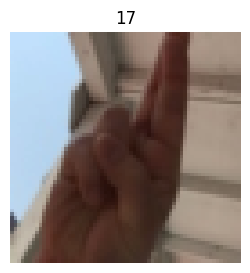

Characteristic vectors: 
[[18.886673   64.79688   ]
 [30.069416   64.08025   ]
 [36.7898     52.259575  ]
 [33.98624    40.483765  ]
 [28.05897    29.708838  ]
 [41.825485   35.77476   ]
 [44.362896   22.180859  ]
 [45.542393   12.76447   ]
 [45.98804     4.5176487 ]
 [34.931217   32.0952    ]
 [40.465504   16.860992  ]
 [43.793427    8.036206  ]
 [46.18078     0.27366114]
 [26.838888   32.494164  ]
 [28.595312   22.107964  ]
 [26.461874   34.06385   ]
 [25.13827    41.54514   ]
 [18.17412    35.926216  ]
 [20.366354   31.079391  ]
 [20.830338   40.828346  ]
 [21.282564   47.28588   ]]


In [56]:
# Sanity check
print("Dataset len:")
print(len(validated_test_dataset))

print("\nDataset classes:")
print(validated_test_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = validated_test_dataset[random.randint(0, len(validated_test_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)


In [57]:
validated_test_dataset_loader = DataLoader(validated_test_dataset, 
                             batch_size=32, 
                             shuffle=False, 
                             num_workers=0)


In [58]:
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = test_model(device, model, validated_test_dataset_loader, criterion)

Test Loss: 0.0131, Test Accuracy: 89.76%
